In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

In [5]:
def read_and_concatenate_metrics(root_folder):
    # Initialize an empty DataFrame to store the concatenated data
    concatenated_data = pd.DataFrame()

    # Debugging: Check if root folder exists
    if not os.path.exists(root_folder):
        print(f"Error: The folder '{root_folder}' does not exist.")
        return concatenated_data

    print(f"Starting to walk through the directory: {root_folder}")

    # Walk through the directory structure
    for root, dirs, files in os.walk(root_folder):

        # Variables to store readme.txt values
        weight_loss_displacement = None
        training_tolerance = None
        
        # Look for the readme.txt file and extract required rows
        if 'readme.txt' in files:
            readme_path = os.path.join(root, 'readme.txt')
            try:
                with open(readme_path, 'r') as readme_file:
                    lines = readme_file.readlines()
                    # Extract specific lines (56 and 58)
                    if len(lines) > 57:  # Ensure line 56 and 58 exist
                        weight_loss_displacement = lines[55].strip().split('=')[1].strip()
                        training_tolerance = lines[57].strip().split('=')[1].strip()
                    else:
                        print(f"Skipping readme.txt in {root}: Not enough lines.")
            except Exception as e:
                print(f"Error reading {readme_path}: {e}")
        
        # Process constrained_mean_metrics.csv file
        for file in files:
            if file == 'constrained_mean_metrics.csv':
                file_path = os.path.join(root, file)
                try:
                    # Read the CSV file
                    df = pd.read_csv(file_path)
                    
                    # Ensure required columns exist
                    if 'metric' in df.columns and 'mean' in df.columns:
                        # Keep only the 'metric' and 'mean' columns
                        df = df[['metric', 'mean','std']]
                        # Add columns for the subfolder name, weight_loss_displacement, and training_tolerance
                        df['source_folder'] = os.path.basename(root)
                        df['weight_loss_displacement'] = weight_loss_displacement
                        df['training_tolerance'] = training_tolerance
                        # Concatenate to the main DataFrame
                        concatenated_data = pd.concat([concatenated_data, df], ignore_index=True)
                    else:
                        print(f"Skipping file {file_path}: Required columns 'metric' and 'mean' not found.")
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")

    return concatenated_data


if __name__ == "__main__":
    # Specify the root folder containing subfolders named "run*"
    root_folder = r"..\training_output\function_fitting\lambda_epsilon_5runs"

    # Call the function and get the concatenated DataFrame
    concatenated_data = read_and_concatenate_metrics(root_folder)

    # Check if any data was read
    if not concatenated_data.empty:
        # Save the result to a CSV file (optional)
        output_file = "../training_output/processed/concatenated_metrics_5runs_std.csv"
        concatenated_data.to_csv(output_file, index=False)
        print(f"Concatenated metrics saved to {output_file}")
    else:
        print("No data was found. Please check the folder structure or file contents.")

Starting to walk through the directory: ..\training_output\function_fitting\lambda_epsilon_5runs
Concatenated metrics saved to ../training_output/processed/concatenated_metrics_5runs_std.csv


<>:66: SyntaxWarning: invalid escape sequence '\e'
<>:125: SyntaxWarning: invalid escape sequence '\l'
<>:127: SyntaxWarning: invalid escape sequence '\e'
<>:66: SyntaxWarning: invalid escape sequence '\e'
<>:125: SyntaxWarning: invalid escape sequence '\l'
<>:127: SyntaxWarning: invalid escape sequence '\e'
C:\Users\glastrucci\AppData\Local\Temp\ipykernel_24212\2988591731.py:66: SyntaxWarning: invalid escape sequence '\e'
  label=f'$\epsilon_T$: {tolerance}',
C:\Users\glastrucci\AppData\Local\Temp\ipykernel_24212\2988591731.py:125: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Weighting Factor Displacement Loss ($\lambda$)', fontsize=18)  # Increased font size
C:\Users\glastrucci\AppData\Local\Temp\ipykernel_24212\2988591731.py:127: SyntaxWarning: invalid escape sequence '\e'
  plt.legend(title='Training\nTolerance ($\epsilon_T$)', fontsize=18, title_fontsize=20)  # Increased legend font sizes


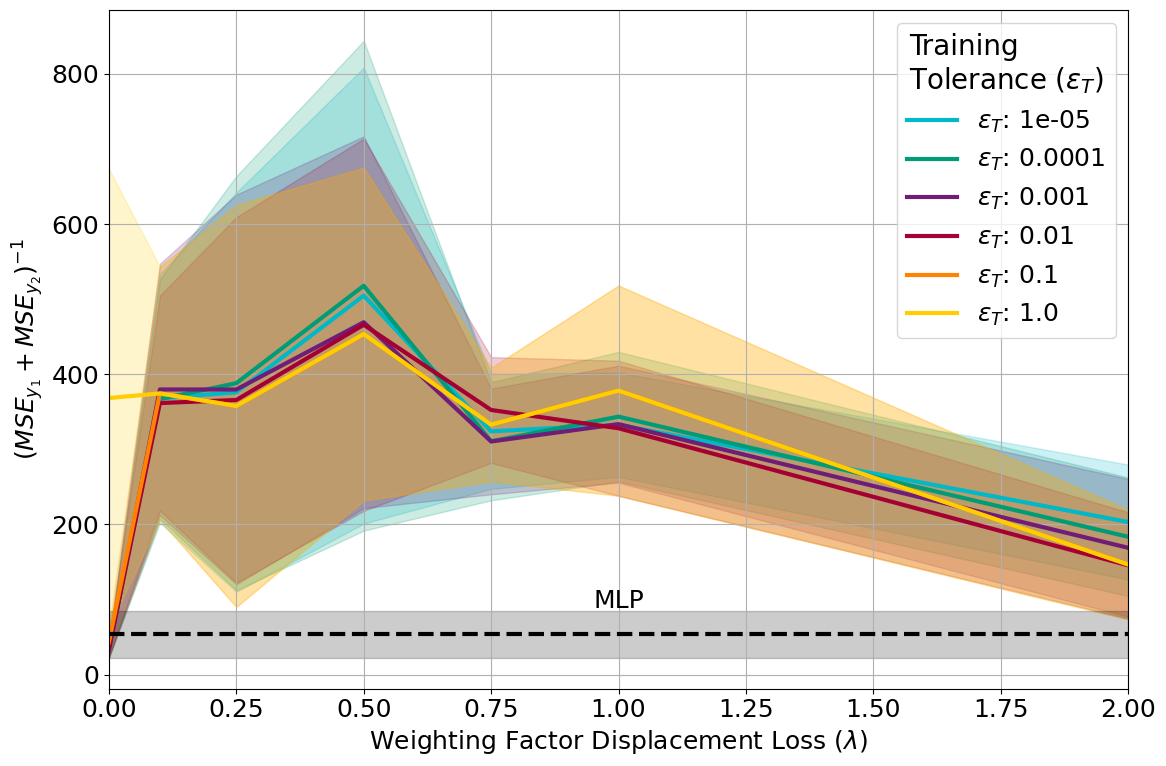

In [6]:
# Create folder to save the figure if it doesn't exist
output_figure_folder = "../training_output/processed/figures"
os.makedirs(output_figure_folder, exist_ok=True)

# File path to the CSV
file_path = "../training_output/processed/concatenated_metrics_5runs_std.csv"  # Update this path if needed

# Load the CSV into a DataFrame
df = pd.read_csv(file_path)

# Filter the metrics for mse_y1, mse_y2, and training_time
mse_y1 = df[df['metric'] == 'mse_y1']
mse_y2 = df[df['metric'] == 'mse_y2']
training_time = df[df['metric'] == 'training_time']

# Merge mse_y1 and mse_y2 on 'source_folder', 'weight_loss_displacement', and 'training_tolerance'
merged = pd.merge(
    mse_y1[['mean', 'std', 'source_folder', 'training_tolerance', 'weight_loss_displacement']],
    mse_y2[['mean', 'std', 'source_folder', 'training_tolerance', 'weight_loss_displacement']],
    on=['source_folder', 'training_tolerance', 'weight_loss_displacement'],
    suffixes=('_y1', '_y2')
)

# Merge the result with training_time
merged = pd.merge(
    merged,
    training_time[['mean', 'std', 'source_folder', 'training_tolerance', 'weight_loss_displacement']],
    on=['source_folder', 'training_tolerance', 'weight_loss_displacement'],
    suffixes=('', '_training_time')
)

# Rename columns for clarity
merged.rename(columns={'mean': 'training_time', 'mean_y1': 'mse_y1', 'mean_y2': 'mse_y2'}, inplace=True)

# Filter out rows where weight_loss_displacement is 0.001
merged = merged[merged['weight_loss_displacement'] != 0.001]

# Calculate 1 / (MSE1 + MSE2)
merged['inverse_mse_sum'] = 1 / (merged['mse_y1'] + merged['mse_y2'])
merged['std_inverse_mse_sum'] = (
    merged['std_y1'] / (merged['mse_y1'] + merged['mse_y2'])**2 +
    merged['std_y2'] / (merged['mse_y1'] + merged['mse_y2'])**2
)

# Define enhanced color palette and shuffle it
enhanced_colors = ['#FFCD00', '#FF8200', '#A50034', '#6F1D77', '#009B77', '#00B8C8']
enhanced_colors = enhanced_colors[::-1]
# random.shuffle(enhanced_colors)

# Group by 'training_tolerance' to create separate lines
plt.figure(figsize=(12, 8))
font_size = 18
plt.rcParams.update({'font.size': font_size})  # Update global font size

for idx, (tolerance, group) in enumerate(list(merged.groupby('training_tolerance'))):
    # Sort by weight_loss_displacement for smooth lines
    group = group.sort_values('weight_loss_displacement')
    
    # Use shuffled colors for each group
    line_color = enhanced_colors[idx % len(enhanced_colors)]
    
    # Plot the mean line
    plt.plot(
        group['weight_loss_displacement'],
        group['inverse_mse_sum'],
        label=f'$\epsilon_T$: {tolerance}',
        color=line_color,
        linestyle='-',
        linewidth = 3
    )
    
    # Plot the standard deviation as a shaded area
    plt.fill_between(
        group['weight_loss_displacement'],
        group['inverse_mse_sum'] - group['std_inverse_mse_sum'],
        group['inverse_mse_sum'] + group['std_inverse_mse_sum'],
        color=line_color,
        alpha=0.2
    )

# Define the unconstrained MSE values
MSE_y1_unconstrained = 0.007887585
MSE_y2_unconstrained = 0.0105990756183092
MSE_y1_unconstrained_std = 0.0075761646555820945
MSE_y2_unconstrained_std = 0.0031512801987446074

# Calculate the inverse MSE sum and its standard deviation
MSE_unconstrained = 1 / (MSE_y1_unconstrained + MSE_y2_unconstrained)
MSE_unconstrained_std = (
    MSE_y1_unconstrained_std / (MSE_y1_unconstrained + MSE_y2_unconstrained)**2 +
    MSE_y2_unconstrained_std / (MSE_y1_unconstrained + MSE_y2_unconstrained)**2
)

# Plot the unconstrained mean as a dashed black line
plt.plot(
    group['weight_loss_displacement'],
    np.ones(len(group['weight_loss_displacement'])) * MSE_unconstrained,
    linestyle='--',
    color='black',
    linewidth=3
    #label='Unconstrained',
)

# Add the standard deviation as a shaded region around the unconstrained line
plt.fill_between(
    group['weight_loss_displacement'],
    np.ones(len(group['weight_loss_displacement'])) * (MSE_unconstrained - MSE_unconstrained_std),
    np.ones(len(group['weight_loss_displacement'])) * (MSE_unconstrained + MSE_unconstrained_std),
    color='black',
    alpha=0.2,
    
)

# Annotate "unconstrained" above the dashed line
plt.text(
    group['weight_loss_displacement'].iloc[-2],
    MSE_unconstrained + 35,  # Slightly above the dashed line
    "MLP",
    color='black',
    fontsize=18,
    ha='center'
)

# Add labels, title, and legend with larger font sizes
plt.xlabel('Weighting Factor Displacement Loss ($\lambda$)', fontsize=18)  # Increased font size
plt.ylabel('$(MSE_{y_1} + MSE_{y_2})^{-1}$', fontsize=18)  # Increased font size
plt.legend(title='Training\nTolerance ($\epsilon_T$)', fontsize=18, title_fontsize=20)  # Increased legend font sizes
plt.grid(True)
plt.xlim([0, 2])

# Show the plot
plt.tight_layout()
plt.savefig("../training_output/processed/figures/lambda_epsilon.pdf", format="pdf", bbox_inches="tight")
plt.show()


<>:55: SyntaxWarning: invalid escape sequence '\l'
<>:75: SyntaxWarning: invalid escape sequence '\e'
<>:76: SyntaxWarning: invalid escape sequence '\e'
<>:55: SyntaxWarning: invalid escape sequence '\l'
<>:75: SyntaxWarning: invalid escape sequence '\e'
<>:76: SyntaxWarning: invalid escape sequence '\e'
C:\Users\glastrucci\AppData\Local\Temp\ipykernel_24212\191620985.py:55: SyntaxWarning: invalid escape sequence '\l'
  label=f"$\lambda$: {displacement}",  # Use the grouped displacement label
C:\Users\glastrucci\AppData\Local\Temp\ipykernel_24212\191620985.py:75: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Constraint tolerance training ($\epsilon_T$)', fontsize=18)  # Increased font size
C:\Users\glastrucci\AppData\Local\Temp\ipykernel_24212\191620985.py:76: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('# NP Layers - Inference ($\epsilon_I=10^{-6}$)', fontsize=18)  # Increased font size


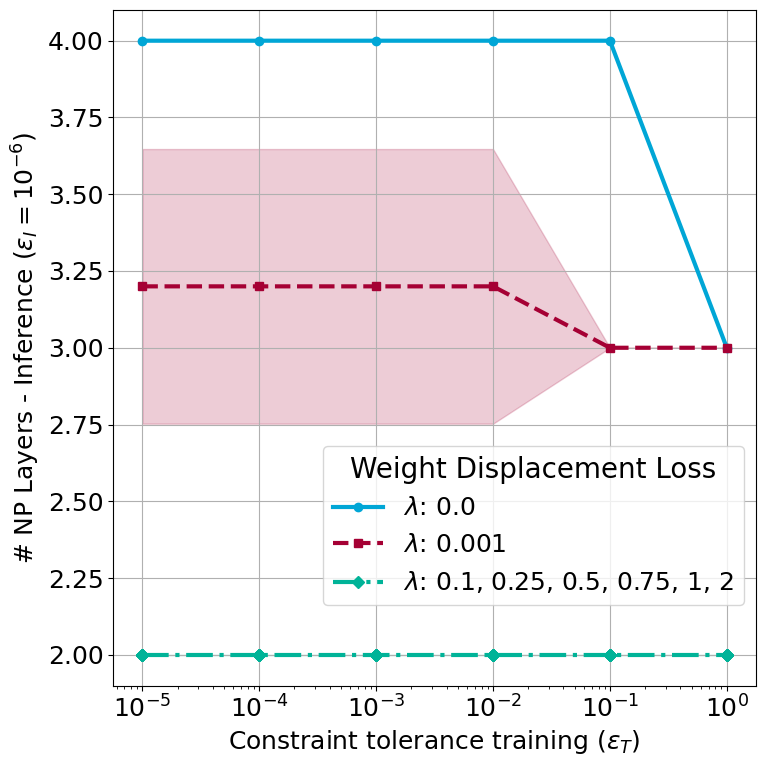

In [7]:
# File path to the CSV
file_path = "../training_output/processed/concatenated_metrics_5runs_std.csv"  # Update this path if needed

# Load the CSV into a DataFrame
df = pd.read_csv(file_path)

# Filter the data for 'mse_y1' for weight_loss_displacement and training_tolerance
filtered_mse_y1 = df[df['metric'] == 'mse_y1']

# Filter the data for 'projection iterations' to get its values
filtered_projection_iterations = df[df['metric'] == 'projection iterations']

# Ensure both filtered DataFrames are aligned on source_folder or other identifiers
merged_df = pd.merge(
    filtered_mse_y1,
    filtered_projection_iterations[['mean', 'std', 'source_folder']],
    on='source_folder',
    suffixes=('_mse_y1', '_projection_iterations')
)

# Group the specific weight_loss_displacement values into a single group
merged_df['grouped_displacement'] = merged_df['weight_loss_displacement'].apply(
    lambda x: '0.1, 0.25, 0.5, 0.75, 1, 2' if x in [0.1, 0.25, 0.5, 0.75, 1, 2] else f'{x}'
)

# Group the data by grouped_displacement
grouped = merged_df.groupby('grouped_displacement')

# Define TU Delft colors
tu_delft_colors = ['#00A6D6', '#A50034', '#00B398', '#FFCD00']
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^', 'v', 'p', '*']
num_colors = len(tu_delft_colors)
num_styles = len(line_styles)
num_markers = len(markers)

# Create the plot
plt.figure(figsize=(8, 8))
font_size = 18
plt.rcParams.update({'font.size': font_size})  # Update global font size

# Iterate through each group and plot with TU Delft colors, varying line styles and markers
for idx, (displacement, group) in enumerate(grouped):
    line_color = tu_delft_colors[idx % num_colors]  # Cycle through TU Delft colors
    line_style = line_styles[idx % num_styles]  # Cycle through line styles
    marker = markers[idx % num_markers]  # Cycle through markers
    
    # Sort by training_tolerance for smooth plotting
    group = group.sort_values('training_tolerance')
    
    # Plot the mean line
    plt.plot(
        group['training_tolerance'],
        group['mean_projection_iterations'],
        label=f"$\lambda$: {displacement}",  # Use the grouped displacement label
        linestyle=line_style,
        marker=marker,
        color=line_color,
        linewidth=3
    )
    
    # Add shaded region for standard deviation
    plt.fill_between(
        group['training_tolerance'],
        group['mean_projection_iterations'] - group['std_projection_iterations'],
        group['mean_projection_iterations'] + group['std_projection_iterations'],
        color=line_color,
        alpha=0.2
    )

# Set log scale on the x-axis
plt.xscale('log')

# Add labels, title, and legend with increased font sizes
plt.xlabel('Constraint tolerance training ($\epsilon_T$)', fontsize=18)  # Increased font size
plt.ylabel('# NP Layers - Inference ($\epsilon_I=10^{-6}$)', fontsize=18)  # Increased font size
#plt.title('Projection Iterations vs Training Tolerance by Weight Loss Displacement', fontsize=16)  # Larger title

# Position the legend on the left, vertically centered
plt.legend(
    title='Weight Displacement Loss',
    loc='lower right',
    bbox_to_anchor=(1, 0.1),  # Move the legend outside the plot to the left
    fontsize=18,
    title_fontsize=20
)

plt.grid(True)
plt.rc('xtick', labelsize=18)  # X-axis tick labels
plt.rc('ytick', labelsize=18)  # Y-axis tick labels


# Show the plot
plt.tight_layout()
plt.savefig("../training_output/processed/figures/NPs_inference_with_tu_delft_colors.pdf", format="pdf", bbox_inches="tight")


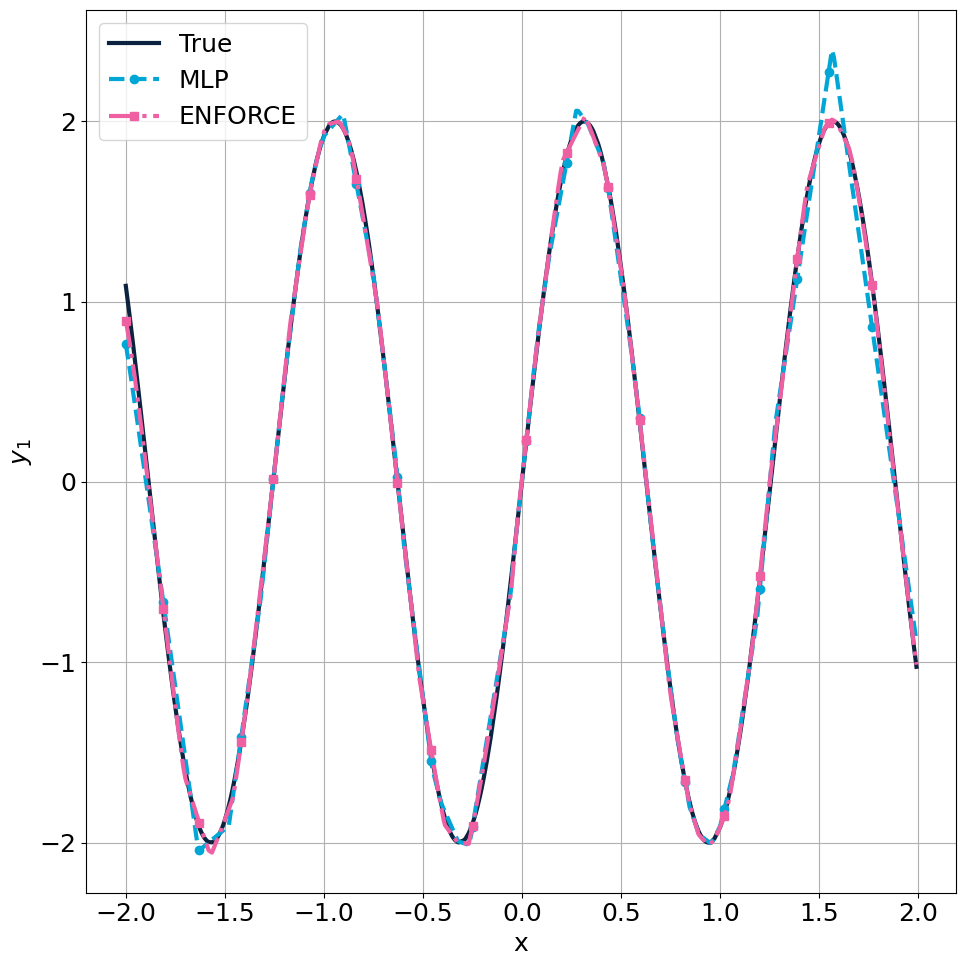

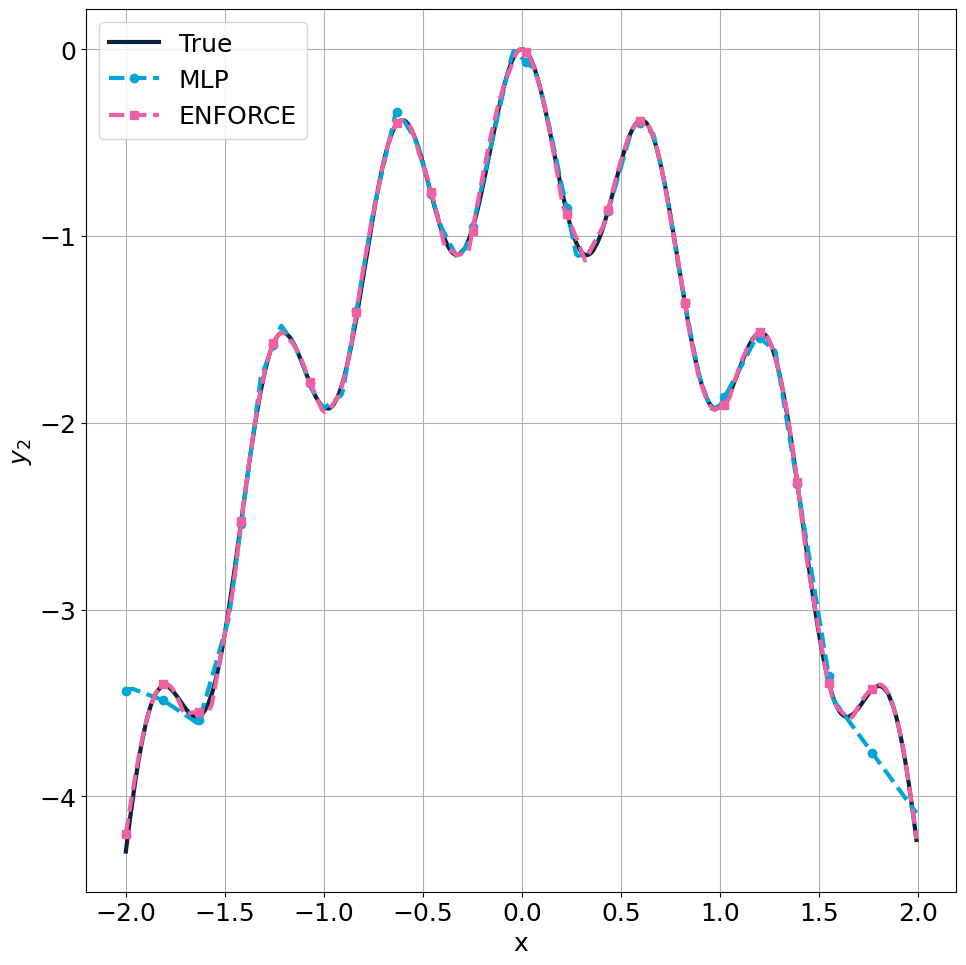

In [8]:
# File paths
original_test = r'..\training_output\function_fitting\lambda_epsilon\run_20241119_011919\test_dataset\constrained_test_data.csv'
prediction_u = r'..\training_output\function_fitting\lambda_epsilon\run_20241119_011919\test_predictions\unconstrained_test_predictions_run_1.csv'
prediction_c = r'..\training_output\function_fitting\lambda_epsilon\run_20241119_011919\test_predictions\constrained_test_predictions_run_1.csv'

# Load data
original_df = pd.read_csv(original_test)
prediction_u_df = pd.read_csv(prediction_u)
prediction_c_df = pd.read_csv(prediction_c)

# Sort data by x
original_df = original_df.sort_values(by='x')
prediction_u_df = prediction_u_df.sort_values(by='x')
prediction_c_df = prediction_c_df.sort_values(by='x')

# Plot settings
line_width = 3
font_size = 18
plt.rcParams.update({'font.size': font_size})  # Update global font size

# Helper to reduce markers for visibility
marker_interval = 50  # Show marker every 10 points

# Plot y1
plt.figure(figsize=(10, 10))
plt.plot(original_df['x'], original_df['y1_true'], label='True', linestyle='-', linewidth=line_width, color='#0C2340')
plt.plot(prediction_u_df['x'], prediction_u_df['y1_pred'], label='MLP', linestyle='--', linewidth=line_width, color='#00A6D6', marker='o', markevery=marker_interval)
plt.plot(prediction_c_df['x'], prediction_c_df['y1_pred'], label='ENFORCE', linestyle='-.', linewidth=line_width, color='#EF60A3', marker='s', markevery=marker_interval)
plt.xlabel('x')
plt.ylabel('$y_1$')
plt.legend(loc='upper left', fontsize=18)
plt.grid(True)
plt.tight_layout()
plt.savefig('../training_output/processed/figures/y1_vs_x_improved.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Plot y2
plt.figure(figsize=(10, 10))
plt.plot(original_df['x'], original_df['y2_true'], label='True', linestyle='-', linewidth=line_width, color='#0C2340')
plt.plot(prediction_u_df['x'], prediction_u_df['y2_pred'], label='MLP', linestyle='--', linewidth=line_width, color='#00A6D6', marker='o', markevery=marker_interval)
plt.plot(prediction_c_df['x'], prediction_c_df['y2_pred'], label='ENFORCE', linestyle='--', linewidth=line_width, color='#EF60A3', marker='s', markevery=marker_interval)

plt.rc('xtick', labelsize=18)  # X-axis tick labels
plt.rc('ytick', labelsize=18)  # Y-axis tick labels
plt.xlabel('x')
plt.ylabel('$y_2$')
plt.legend(loc='upper left', fontsize=18)
plt.grid(True)
plt.tight_layout()
plt.savefig('../training_output/processed/figures/y2_vs_x_improved.pdf', format='pdf', bbox_inches='tight')
plt.show()


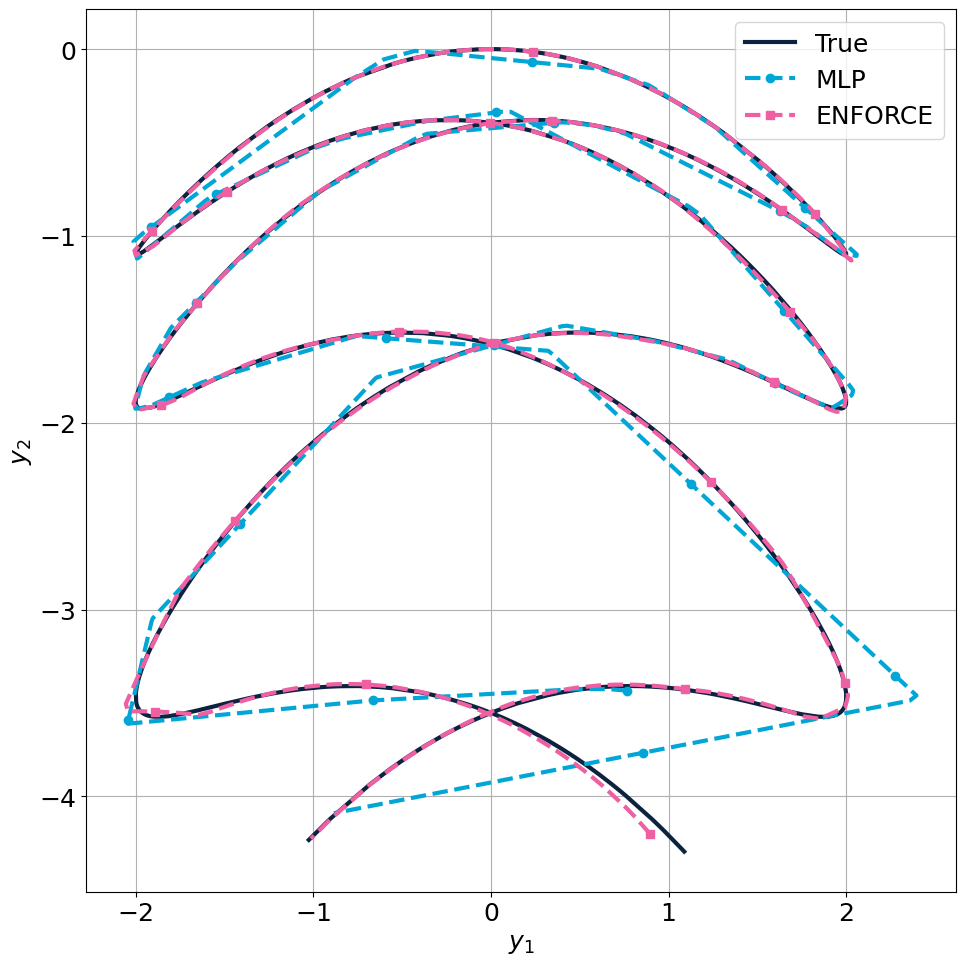

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Updated File paths
original_test = r'..\training_output\function_fitting\lambda_epsilon\run_20241119_011919\test_dataset\constrained_test_data.csv'
prediction_u = r'..\training_output\function_fitting\lambda_epsilon\run_20241119_011919\test_predictions\unconstrained_test_predictions_run_1.csv'
prediction_c = r'..\training_output\function_fitting\lambda_epsilon\run_20241119_011919\test_predictions\constrained_test_predictions_run_1.csv'

# Load data
original_df = pd.read_csv(original_test)
prediction_u_df = pd.read_csv(prediction_u)
prediction_c_df = pd.read_csv(prediction_c)

# Sort data by x for consistent ordering
original_df = original_df.sort_values(by='x')
prediction_u_df = prediction_u_df.sort_values(by='x')
prediction_c_df = prediction_c_df.sort_values(by='x')

# Plot settings
line_width = 3
font_size = 18
plt.rc('xtick', labelsize=18)  # X-axis tick labels
plt.rc('ytick', labelsize=18)  # Y-axis tick labels
plt.rcParams.update({'font.size': font_size})  # Update global font size
marker_interval = 50  # Show marker every 10 points
# Plot y1 vs y2
plt.figure(figsize=(10, 10))
plt.plot(original_df['y1_true'], original_df['y2_true'], label='True', linestyle='-', linewidth=line_width, color='#0C2340')
plt.plot(prediction_u_df['y1_pred'], prediction_u_df['y2_pred'], label='MLP', linestyle='--', linewidth=line_width, color='#00A6D6', marker='o', markevery=marker_interval)
plt.plot(prediction_c_df['y1_pred'], prediction_c_df['y2_pred'], label='ENFORCE', linestyle='--', linewidth=line_width, color='#EF60A3', marker='s', markevery=marker_interval)
plt.xlabel('$y_1$')
plt.ylabel('$y_2$')
plt.legend(loc='upper right', fontsize=18)
plt.grid(True)
plt.tight_layout()
plt.savefig('../training_output/processed/figures/y1_y2_plane.pdf', format="pdf", bbox_inches="tight")
plt.show()


<>:106: SyntaxWarning: invalid escape sequence '\e'
<>:106: SyntaxWarning: invalid escape sequence '\e'
C:\Users\glastrucci\AppData\Local\Temp\ipykernel_24212\92812747.py:106: SyntaxWarning: invalid escape sequence '\e'
  ax2.set_ylabel('# NP Layers ($\epsilon_T = 10^{-4}$)', fontsize=18)


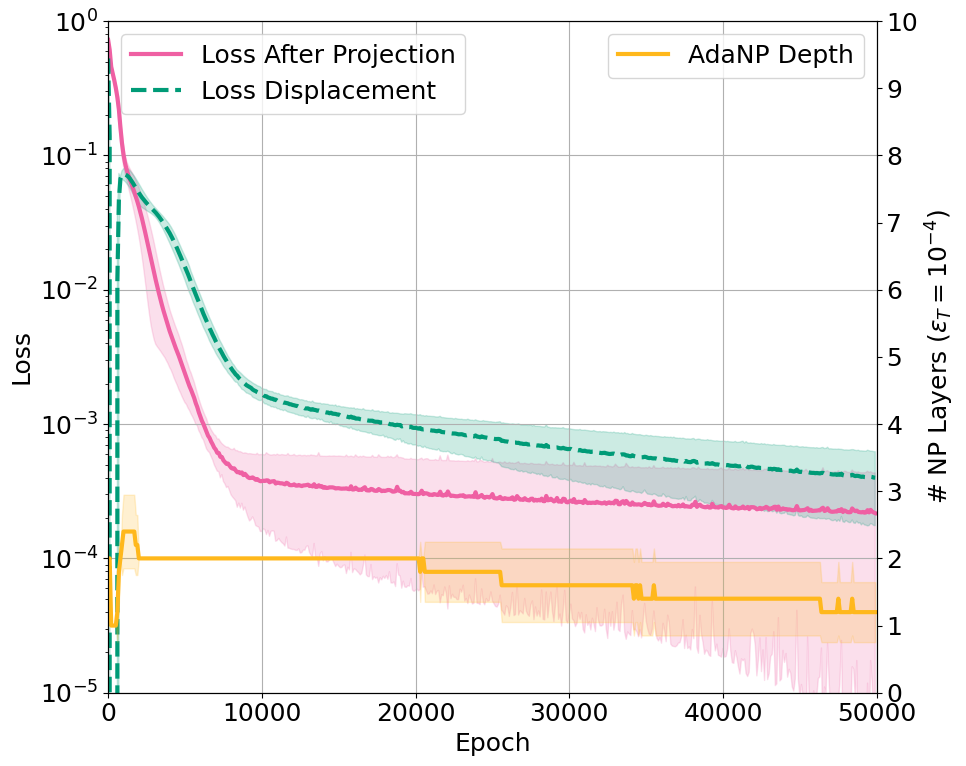

In [10]:
# Define the file pattern to match the five files
file_pattern = r"..\training_output\function_fitting\run_20241122_131622_ref5runs\losses\constrained_losses_run_*.csv"  # Replace 'path_to_folder' with the actual path

# Load all files matching the pattern into a single DataFrame
all_files = glob.glob(file_pattern)
dataframes = [pd.read_csv(file) for file in all_files]

# Concatenate all data into a single DataFrame
data = pd.concat(dataframes, ignore_index=True)

# Group by 'epoch' and compute mean and standard deviation
grouped = data.groupby('epoch').agg(['mean', 'std']).reset_index()

# Flatten the MultiIndex columns
grouped.columns = ['_'.join(col).strip('_') for col in grouped.columns]

# Extract required columns for plotting
epochs = grouped['epoch']
loss_after_mean = grouped['loss_data_after_projection_mean']
loss_after_std = grouped['loss_data_after_projection_std']
loss_disp_mean = grouped['loss_displacement_mean']
loss_disp_std = grouped['loss_displacement_std']
proj_iter_mean = grouped['projection_iterations_mean']
proj_iter_std = grouped['projection_iterations_std']

# Downsample the data to plot fewer points
downsample_rate = 100  # Adjust this to control how many points are plotted
epochs_downsampled = epochs[::downsample_rate]
loss_after_mean_downsampled = loss_after_mean[::downsample_rate]
loss_after_std_downsampled = loss_after_std[::downsample_rate]
loss_disp_mean_downsampled = loss_disp_mean[::downsample_rate]
loss_disp_std_downsampled = loss_disp_std[::downsample_rate]
proj_iter_mean_downsampled = proj_iter_mean[::downsample_rate]
proj_iter_std_downsampled = proj_iter_std[::downsample_rate]

# Define the color palette and randomize the order
color_palette = ['#EF60A3', '#009B77', '#FFB81C']

# Assign colors
loss_after_color = color_palette[0]
loss_disp_color = color_palette[1]
proj_iter_color = color_palette[2]

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 8))


# Plot loss_data_after_projection (left y-axis)
ax1.plot(
    epochs_downsampled,
    loss_after_mean_downsampled,
    label='Loss After Projection',
    color=loss_after_color,
    linestyle='-',
    linewidth=3
)
ax1.fill_between(
    epochs_downsampled,
    loss_after_mean_downsampled - loss_after_std_downsampled,
    loss_after_mean_downsampled + loss_after_std_downsampled,
    color=loss_after_color,
    alpha=0.2
)

# Plot loss_displacement (left y-axis)
ax1.plot(
    epochs_downsampled,
    loss_disp_mean_downsampled,
    label='Loss Displacement',
    color=loss_disp_color,
    linestyle='--',
    linewidth=3
)
ax1.fill_between(
    epochs_downsampled,
    loss_disp_mean_downsampled - loss_disp_std_downsampled,
    loss_disp_mean_downsampled + loss_disp_std_downsampled,
    color=loss_disp_color,
    alpha=0.2
)

# Log scale for left y-axis
ax1.set_yscale('log')
ax1.set_xlabel('Epoch', fontsize=18)
ax1.set_ylabel('Loss', fontsize=18)
ax1.legend(loc='upper left', fontsize=18)
ax1.set_ylim(1e-5, 1)

# Create second y-axis for projection iterations
ax2 = ax1.twinx()
ax2.plot(
    epochs_downsampled,
    proj_iter_mean_downsampled,
    label='AdaNP Depth',
    color=proj_iter_color,
    linestyle='-',
    linewidth=3
)
ax2.fill_between(
    epochs_downsampled,
    proj_iter_mean_downsampled - proj_iter_std_downsampled,
    proj_iter_mean_downsampled + proj_iter_std_downsampled,
    color=proj_iter_color,
    alpha=0.2
)
ax2.set_ylabel('# NP Layers ($\epsilon_T = 10^{-4}$)', fontsize=18)

# Add grid, legend, and title
ax1.grid(True)
ax2.legend(loc='upper right', fontsize=18)
ax2.set_ylim(0, 10)
ax2.set_yticks(range(0, 11, 1))
ax2.set_xlim(0, 50000)
plt.rc('xtick', labelsize=18)  # X-axis tick labels
plt.rc('ytick', labelsize=18)  # Y-axis tick labels
# Tight layout and save the plot
plt.tight_layout()
plt.savefig("../training_output/processed/figures/loss_and_projection_iterations_downsampled.pdf", format="pdf", bbox_inches="tight")
plt.show()


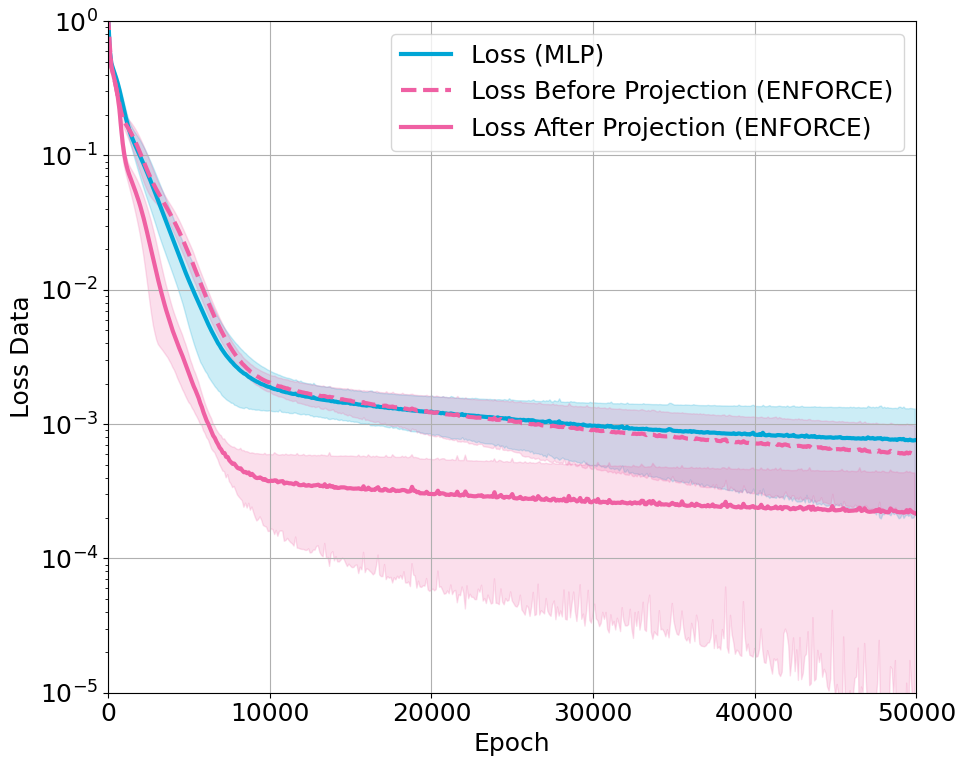

In [11]:
# Define the file patterns to match the files
constrained_pattern = r"..\training_output\function_fitting\run_20241122_131622_ref5runs\losses\constrained_losses_run_*.csv"
unconstrained_pattern = r"..\training_output\function_fitting\run_20241122_131622_ref5runs\losses\unconstrained_losses_run_*.csv"

# Load all constrained files
constrained_files = glob.glob(constrained_pattern)
constrained_dataframes = [pd.read_csv(file) for file in constrained_files]
constrained_data = pd.concat(constrained_dataframes, ignore_index=True)

# Group by 'epoch' and compute mean and standard deviation for constrained losses
constrained_grouped = constrained_data.groupby('epoch').agg(['mean', 'std']).reset_index()
constrained_grouped.columns = ['_'.join(col).strip('_') for col in constrained_grouped.columns]

# Extract constrained loss columns
epochs = constrained_grouped['epoch']
loss_after_mean = constrained_grouped['loss_data_after_projection_mean']
loss_after_std = constrained_grouped['loss_data_after_projection_std']
loss_before_mean = constrained_grouped['loss_data_before_projection_mean']
loss_before_std = constrained_grouped['loss_data_before_projection_std']

# Load all unconstrained files
unconstrained_files = glob.glob(unconstrained_pattern)
unconstrained_dataframes = [pd.read_csv(file) for file in unconstrained_files]
unconstrained_data = pd.concat(unconstrained_dataframes, ignore_index=True)

# Group by 'epoch' and compute mean and standard deviation for unconstrained losses
unconstrained_grouped = unconstrained_data.groupby('epoch').agg(['mean', 'std']).reset_index()
unconstrained_grouped.columns = ['_'.join(col).strip('_') for col in unconstrained_grouped.columns]

# Extract unconstrained loss columns
loss_unconstrained_mean = unconstrained_grouped['loss_unconstrained_mean']
loss_unconstrained_std = unconstrained_grouped['loss_unconstrained_std']

# Downsample the data to plot fewer points
downsample_rate = 100  # Adjust this to control how many points are plotted (higher = fewer points)
epochs_downsampled = epochs[::downsample_rate]
loss_after_mean_downsampled = loss_after_mean[::downsample_rate]
loss_after_std_downsampled = loss_after_std[::downsample_rate]
loss_before_mean_downsampled = loss_before_mean[::downsample_rate]
loss_before_std_downsampled = loss_before_std[::downsample_rate]
loss_unconstrained_mean_downsampled = loss_unconstrained_mean[::downsample_rate]
loss_unconstrained_std_downsampled = loss_unconstrained_std[::downsample_rate]

# Define the color palette
color_constrained = '#EF60A3'  # Same color for constrained losses
color_unconstrained = '#00A6D6'  # Different color for unconstrained loss

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot loss_unconstrained
ax.plot(
    epochs_downsampled,
    loss_unconstrained_mean_downsampled,
    label='Loss (MLP)',
    color=color_unconstrained,
    linestyle='-',
    linewidth=3
)
ax.fill_between(
    epochs_downsampled,
    loss_unconstrained_mean_downsampled - loss_unconstrained_std_downsampled,
    loss_unconstrained_mean_downsampled + loss_unconstrained_std_downsampled,
    color=color_unconstrained,
    alpha=0.2
)

# Plot loss_before_projection (constrained)
ax.plot(
    epochs_downsampled,
    loss_before_mean_downsampled,
    label='Loss Before Projection (ENFORCE)',
    color=color_constrained,
    linestyle='--',
    linewidth=3
)
ax.fill_between(
    epochs_downsampled,
    loss_before_mean_downsampled - loss_before_std_downsampled,
    loss_before_mean_downsampled + loss_before_std_downsampled,
    color=color_constrained,
    alpha=0.2
)

# Plot loss_after_projection (constrained)
ax.plot(
    epochs_downsampled,
    loss_after_mean_downsampled,
    label='Loss After Projection (ENFORCE)',
    color=color_constrained,
    linestyle='-',
    linewidth=3
)
ax.fill_between(
    epochs_downsampled,
    loss_after_mean_downsampled - loss_after_std_downsampled,
    loss_after_mean_downsampled + loss_after_std_downsampled,
    color=color_constrained,
    alpha=0.2
)

# Set log scale for y-axis
ax.set_yscale('log')
ax.set_xlabel('Epoch', fontsize=18)
ax.set_ylabel('Loss Data', fontsize=18)
ax.legend(loc='upper right', fontsize=18)
ax.set_ylim(1e-5, 1)  # Adjust as needed for your data
ax.set_xlim(0, 50000)


# Add grid and title
ax.grid(True)
plt.rc('xtick', labelsize=18)  # X-axis tick labels
plt.rc('ytick', labelsize=18)  # Y-axis tick labels
# Tight layout and save the plot
plt.tight_layout()
plt.savefig("../training_output/processed/figures/loss_comparison_downsampled.pdf", format="pdf", bbox_inches="tight")
plt.show()

<>:79: SyntaxWarning: invalid escape sequence '\e'
<>:95: SyntaxWarning: invalid escape sequence '\e'
<>:79: SyntaxWarning: invalid escape sequence '\e'
<>:95: SyntaxWarning: invalid escape sequence '\e'
C:\Users\glastrucci\AppData\Local\Temp\ipykernel_24212\2748394574.py:79: SyntaxWarning: invalid escape sequence '\e'
  label=f'$\epsilon_T$: {tolerance}',
C:\Users\glastrucci\AppData\Local\Temp\ipykernel_24212\2748394574.py:95: SyntaxWarning: invalid escape sequence '\e'
  plt.legend(title='Training\nTolerance ($\epsilon_T$)', fontsize=18, title_fontsize=20, loc='upper right')


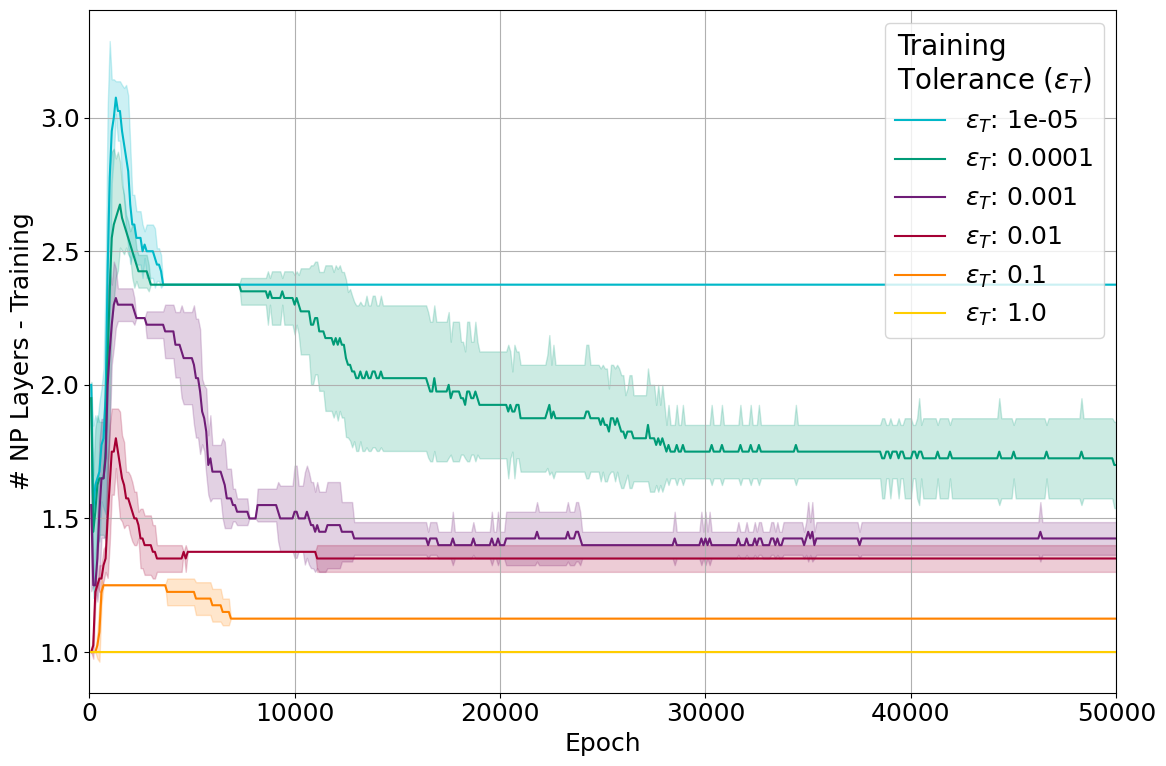

In [12]:
# Define the path to the main folder
main_folder = r'..\training_output\function_fitting\lambda_epsilon_5runs'

# Initialize an empty list to store data from each subfolder
data_list = []

# Loop over each subfolder to read and extract data
for subfolder in os.listdir(main_folder):
    subfolder_path = os.path.join(main_folder, subfolder)
    if os.path.isdir(subfolder_path):
        # Paths to the required files
        csv_file = os.path.join(subfolder_path, 'constrained_mean_losses.csv')
        readme_file = os.path.join(subfolder_path, 'readme.txt')
        
        # Check if both files exist
        if os.path.exists(csv_file) and os.path.exists(readme_file):
            # Read the CSV file
            df = pd.read_csv(csv_file)
            
            # Read the readme.md file
            with open(readme_file, 'r') as f:
                lines = f.readlines()
                
                # Check if the readme.md has enough lines
                if len(lines) >= 58:
                    # Extract TRAINING_TOLERANCE and WEIGHT_LOSS_DISPLACEMENT
                    TRAINING_TOLERANCE = float(lines[57].split('=')[1].strip())
                    WEIGHT_LOSS_DISPLACEMENT = float(lines[55].split('=')[1].strip())
                    
                    # Add these values to the DataFrame
                    df['TRAINING_TOLERANCE'] = TRAINING_TOLERANCE
                    df['WEIGHT_LOSS_DISPLACEMENT'] = WEIGHT_LOSS_DISPLACEMENT
                    
                    # Append the DataFrame to the list
                    data_list.append(df)
                else:
                    print(f"readme.md in {subfolder_path} does not have enough lines.")
        else:
            print(f"Required files not found in {subfolder_path}.")

# Concatenate all DataFrames into one
if data_list:
    full_data = pd.concat(data_list, ignore_index=True)
else:
    raise ValueError("No data collected. Please check your folders and files.")

# Group the data by 'TRAINING_TOLERANCE' and 'epoch'
grouped_data = full_data.groupby(['TRAINING_TOLERANCE', 'epoch']).agg({
    'mean_projection_iterations': 'mean',
    'std_projection_iterations': 'mean'  # Averaging std deviations
}).reset_index()

# Filter to plot less frequently (once every 100 epochs)
downsample_rate = 100
grouped_data = grouped_data[grouped_data['epoch'] % downsample_rate == 0]

# Define the custom color palette
color_palette = ['#FFCD00', '#FF8200', '#A50034', '#6F1D77', '#009B77', '#00B8C8']
color_palette = color_palette[::-1]
# Initialize the plot
font_size = 18
plt.rcParams.update({'font.size': font_size})
plt.figure(figsize=(12, 8))


# Get unique tolerances and assign colors
unique_tolerances = sorted(grouped_data['TRAINING_TOLERANCE'].unique())
if len(unique_tolerances) > len(color_palette):
    raise ValueError("Not enough colors in the palette for the number of tolerances.")
    
# Plot each TRAINING_TOLERANCE group
for i, tolerance in enumerate(unique_tolerances):
    tolerance_data = grouped_data[grouped_data['TRAINING_TOLERANCE'] == tolerance]
    
    # Plot the mean projection iterations
    plt.plot(
        tolerance_data['epoch'],
        tolerance_data['mean_projection_iterations'],
        label=f'$\epsilon_T$: {tolerance}',
        color=color_palette[i]
    )
    
    # Plot the standard deviation as a shaded area
    plt.fill_between(
        tolerance_data['epoch'],
        tolerance_data['mean_projection_iterations'] - tolerance_data['std_projection_iterations'],
        tolerance_data['mean_projection_iterations'] + tolerance_data['std_projection_iterations'],
        alpha=0.2,
        color=color_palette[i]
    )

# Customize the plot
plt.xlabel('Epoch', fontsize=18)
plt.ylabel('# NP Layers - Training', fontsize=18)
plt.legend(title='Training\nTolerance ($\epsilon_T$)', fontsize=18, title_fontsize=20, loc='upper right')
plt.grid(True)
plt.rc('xtick', labelsize=18)  # X-axis tick labels
plt.rc('ytick', labelsize=18)  # Y-axis tick labels
plt.xlim(0, 50000)
plt.tight_layout()
plt.savefig("../training_output/processed/figures/proj_training_downsampled.pdf", format="pdf", bbox_inches="tight")
plt.show()


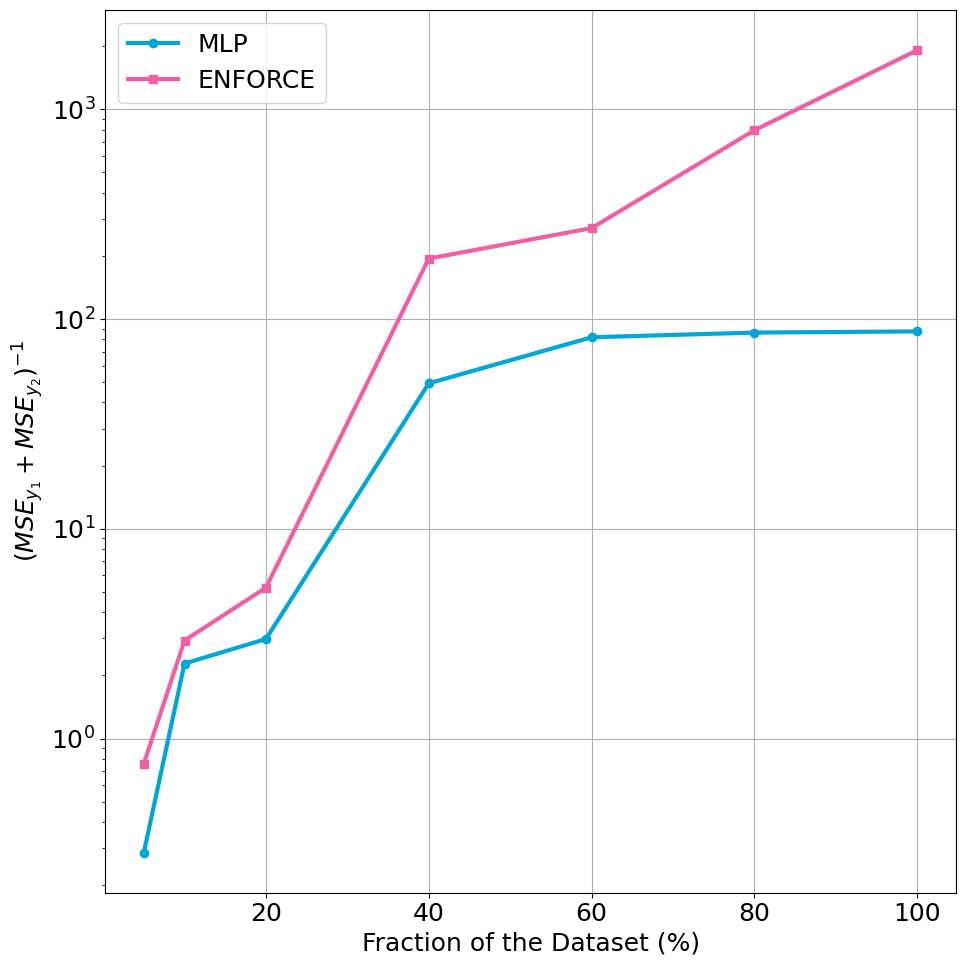

In [13]:
n_datapoints_percent = [5, 10, 20, 40, 60, 80, 100]
mse_y1_c = [2.4159326162940897,0.5547806222114143,0.30629612263897205,0.008641148739773608,0.005767515473266407,0.0019145092017353131,0.0007703022257545601]
mse_y2_c = [0.22030903833024928,0.12704500540895772,0.07520532432376578,0.001665759732478532,0.001603090803569543,0.000604108072952149, 0.0002749369860213671]
mse_c_mean = (np.array(mse_y1_c) + np.array(mse_y2_c))/2
mse_y1_u = [4.762221768644558,0.6805877562549131,0.5804338105731599,0.005309406210510097,0.00903500133168305,0.008976560034728232, 0.007942885521999411]
mse_y2_u = [2.229815563518444,0.1970707277132567,0.09000391471696682,0.0352037985164882,0.015401950756404957,0.014233028818258536, 0.014967493180571056]
mse_u_mean = (np.array(mse_y1_u) + np.array(mse_y2_u))/2
acc_c = 1/mse_c_mean
acc_u = 1/mse_u_mean


# Plot
plt.figure(figsize=(10, 10))
# Define the color palette
color_constrained = '#EF60A3'  # Same color for constrained losses
color_unconstrained = '#00A6D6'  # Different color for unconstrained loss
line_width = 3
plt.plot(n_datapoints_percent, acc_u, marker='o', color=color_unconstrained, linewidth=line_width, label='MLP')
plt.plot(n_datapoints_percent, acc_c, marker='s', color=color_constrained, linewidth=line_width, label='ENFORCE')

# Logarithmic y-axis
plt.yscale('log')

# Labels and title
plt.xlabel('Fraction of the Dataset (%)', fontsize=18)
plt.ylabel('$(MSE_{y_1} + MSE_{y_2})^{-1}$', fontsize=18)
plt.legend()
plt.grid(True)

# Show plot
plt.tight_layout()
plt.savefig("../training_output/processed/figures/data_scarcity.pdf", format="pdf", bbox_inches="tight")
plt.show()